### Probability and Statisctis Spring 2024

### Python Project 
Aysa

Evelyn Feng, af4276

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/Users/f./Desktop/StudentsPerformance.csv")
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
## Find correlations between data atributes
data_corr = data.iloc[:,4:]
data_corr = data_corr.replace({'none':0, 'completed':1})
data_corr.head()

,test preparation course,math score,reading score,writing score
0,0,72,72,74
1,1,69,90,88
2,0,90,95,93
3,0,47,57,44
4,0,76,78,75


In [14]:
def calculate_stats_extended(column):
    mean = column.mean()
    variance = column.var()
    std_dev = column.std()
    median = column.median()
    mode = column.mode()[0] if not column.mode().empty else None
    return mean, variance, std_dev, median, mode

# Assuming we want to analyze specific numerical columns (you can change these names)
columns_to_analyze = ['math score', 'reading score', 'writing score']

results = {}

# Calculate stats for each column
for column_name in columns_to_analyze:
    mean, variance, std_dev, median, mode = calculate_stats_extended(data[column_name])
    results[column_name] = {
        'mean': mean,
        'variance': variance,
        'std_dev': std_dev,
        'median': median,
        'mode': mode
    }

# Display results
for column, stats in results.items():
    print(f"{column}:")
    for stat_name, value in stats.items():
        print(f"{stat_name.capitalize()}: {value}")
    print()


math score:
Mean: 66.089
Variance: 229.91899799799847
Std_dev: 15.163080096009468
Median: 66.0
Mode: 65

reading score:
Mean: 69.169
Variance: 213.1656046046047
Std_dev: 14.60019193725222
Median: 70.0
Mode: 72

writing score:
Mean: 68.054
Variance: 230.90799199199168
Std_dev: 15.195657010869642
Median: 69.0
Mode: 74



<AxesSubplot:>

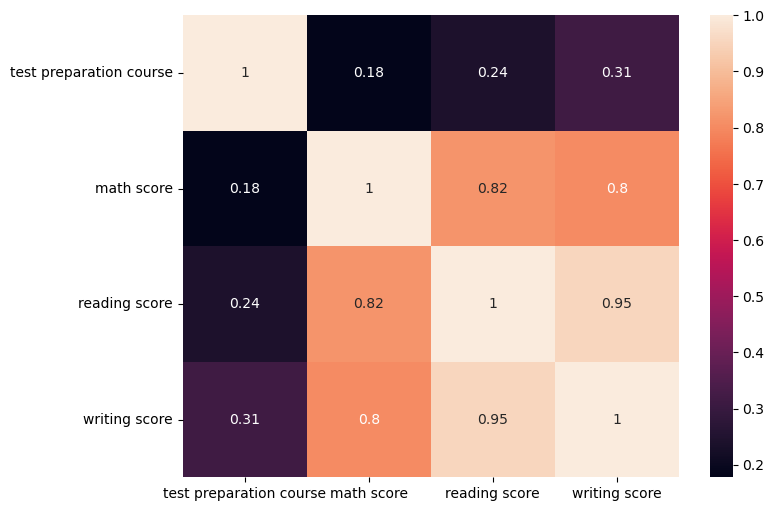

In [5]:
## Correlation
data_corr = data_corr.corr()
plt.figure(figsize=(8,6))
sns.heatmap(data=data_corr, annot=True)

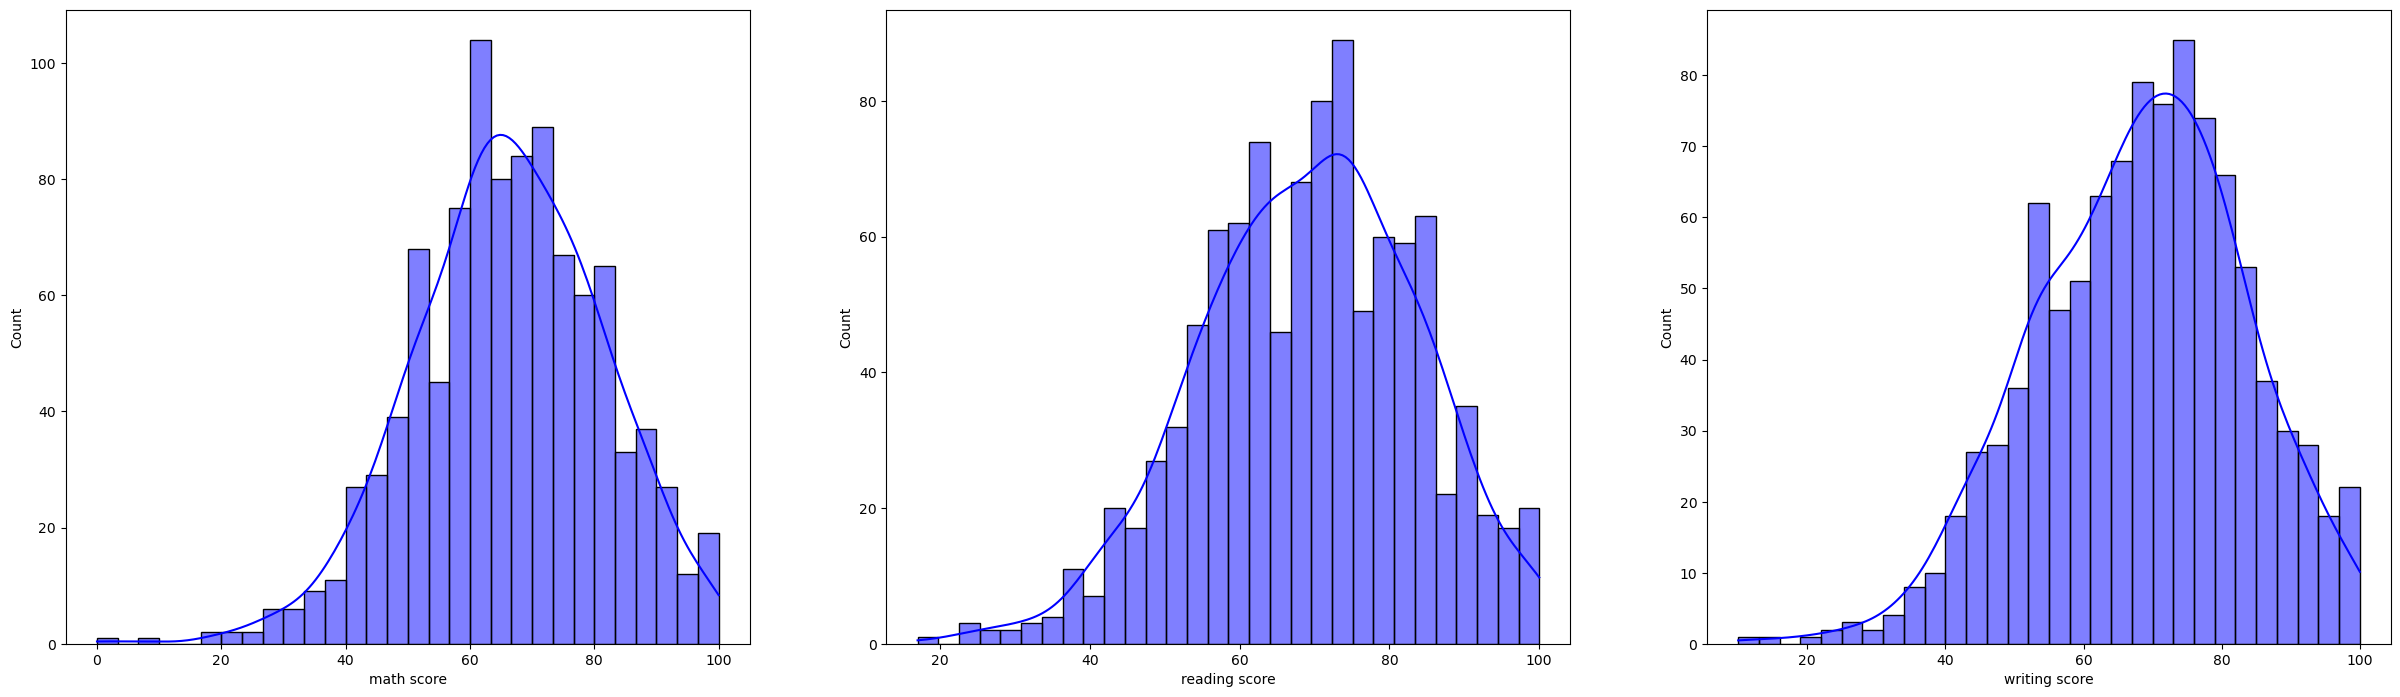

In [6]:
## Visualization of the data of three scores
plt.figure(figsize=(30,28))
for i, col in enumerate(['math score', 'reading score', 'writing score']):
    plt.subplot(3, 3, i+1)
    sns.histplot(data = data,
            x = col,
            kde = True,
            bins = 30,
            color = 'blue')

plt.show()

In [7]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


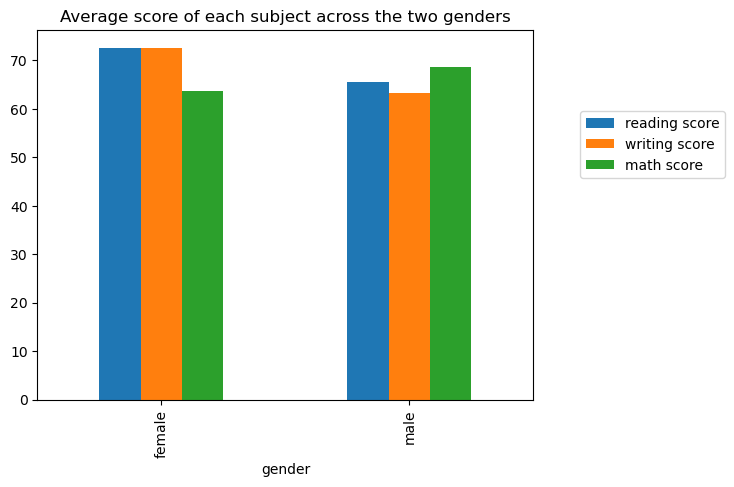

In [8]:
## Average score of male and female
data.groupby("gender")[["reading score","writing score","math score"]].mean().plot(kind="bar",)
plt.legend(bbox_to_anchor=(1.4,0.8))
plt.title("Average score of each subject across the two genders")
plt.show()